# Reinforcement Learning - Fundamental concepts

In [5]:
pip install numpy matplotlib tqdm pandas seaborn plotly

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------  12.3/12.4 MB 69.0 MB/s eta 0:00:01
   ---------------------------------------- 12.4/12.4 MB 56.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 9.3/9.3 MB 125.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 9.8/9.8 MB 103.9 MB/s eta 0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 9.9/9.9 MB 108.4 MB/s eta 0:00:00
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cac


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import plotly.express as px

Matplotlib is building the font cache; this may take a moment.


## Section 1: k-armed bandit 

The k-armed bandit problem is a classic example in reinforcement learning that illustrates the trade-off between exploration and exploitation. Imagine a slot machine with $ k $ arms, where each arm represents a different action the agent can take. When an arm is pulled, it provides a reward based on an unknown probability distribution unique to that arm. The goal is to find a strategy that maximizes the total reward over time by balancing two competing objectives: exploring less-known arms to gather more information about their reward distributions and exploiting the arms that are believed to yield the highest rewards. This problem serves as a simplified framework for understanding decision-making under uncertainty, making it a fundamental building block for more complex reinforcement learning algorithms.

Let’s start by building our k-armed bandit environment. This environment will simulate $ k $ different arms, each with its own reward distribution. When the agent pulls an arm, the environment will return a reward based on the corresponding distribution. To create this, we’ll initialize $ k $ reward probabilities or mean values, which will define the behavior of each arm. The environment will also handle the interaction with the agent, providing rewards and keeping track of the agent’s actions. By designing this environment, we lay the groundwork for testing various strategies to solve the k-armed bandit problem effectively.

In [3]:
np.random.normal(0,5,10)

array([ 2.57616219,  1.08528301, -1.01148038,  1.80928855,  0.50596661,
       -2.98678055,  1.06498443,  4.8622131 ,  1.62753486, -8.50129524])

In [29]:
class KarmedBanditEnvironment:
    def __init__(self, num_bandits: int):
        """
        Initializes the K-armed Bandit environment with a specified number of bandits.

        Args:
            num_bandits (int): The number of bandits (actions) in the environment.

        Initializes:
            - bandit_means: Mean values for the reward distribution of each bandit, drawn from a normal distribution.
            - bandit_std: Standard deviation values for each bandit's reward distribution, drawn from a normal distribution.
        """
        self.bandit_means = np.random.normal(0,1,num_bandits)
        self.bandit_std = np.abs(np.random.normal(0,1,num_bandits))

    def step(self, action: int):
        """
        Executes a step in the environment based on the chosen action.

        Args:
            action (int): The index of the bandit (action) chosen by the agent.

        Returns:
            float: The reward for the chosen action, sampled from a normal distribution 
                   with the mean and standard deviation of the selected bandit.
        """
        
        return np.random.normal(self.bandit_means[action],self.bandit_std[action])
        

    def reset(self):
        """
        Resets the environment to its initial state.
        """
        self.__init__(len(self.bandit_means))

    def plot(self):
        """
        Plots the reward distributions of each bandit using violin plots.

        This method visualizes the reward distributions of each bandit based on the 
        mean and standard deviation values initialized for each bandit. The violin plots 
        help to understand the distribution of rewards for each action.
        """
        plt.figure(figsize=(14,6))
        df = pd.DataFrame()
        for i in range(len(self.bandit_means)):
            temp_df = pd.DataFrame({'Distribution':i,'Value':np.random.normal(self.bandit_means[i],self.bandit_std[i],10000)})
            df = pd.concat([df,temp_df])
        sns.violinplot(data=df,y='Value',hue='Distribution',x='Distribution',legend=False)
        

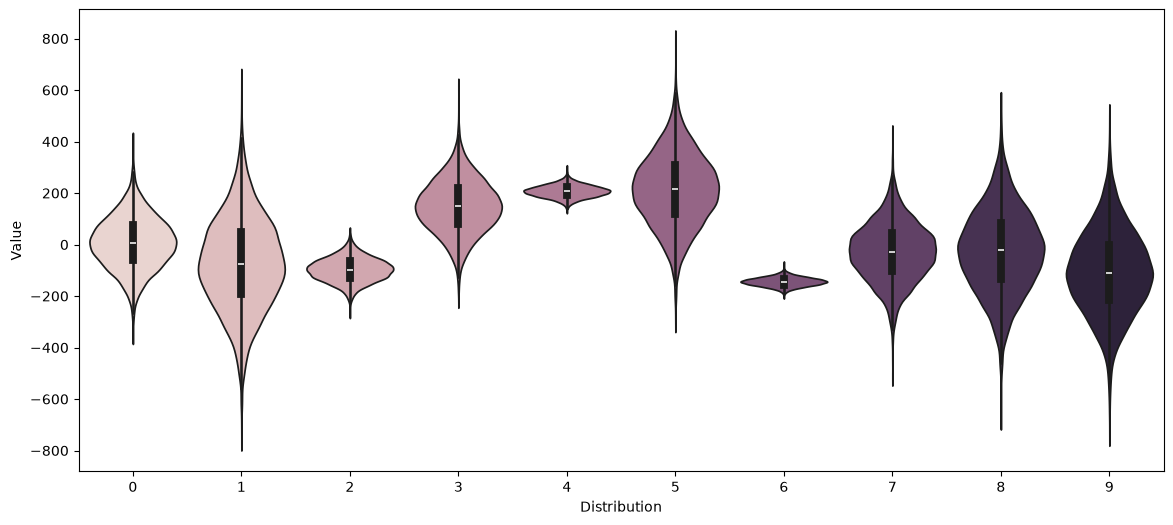

In [5]:
env = KarmedBanditEnvironment(10)
env.plot()

Now that you have a functional environment, let's test it with our first agent.

## Section 2: Greedy Agent

Our goal is to design an agent capable of identifying the action with the greatest expected reward. A straightforward approach for the agent is to consistently pick the action it currently believes to have the highest value. This behavior defines what we call a "greedy agent," as it focuses solely on maximizing its immediate estimated value. Let's examine the implications of this strategy.  

To begin, we’ll create a custom implementation of the argmax function. This function will take a list of action values as input and return the action with the highest value. But why not simply use NumPy’s built-in argmax? The reason lies in how NumPy handles ties—it always returns the first instance of the maximum value, introducing a bias toward certain actions. To avoid this, we’ll write our own argmax function that breaks ties randomly. Consider using [np.random.choice](https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.choice.html), which can help in randomly selecting between equally high values.

In [6]:
def argmax(q_values: list)->int:
    """
    Takes in a list of q_values and returns the index of the item
    with the highest value. Breaks ties randomly.
    returns: int - the index of the highest value in q_values
    """
    arr_q_values = np.array(q_values)
    return np.random.choice(np.where(arr_q_values == arr_q_values.max())[0])

Next, we’ll start building the first component of the agent that you’ll develop. Specifically, we’ll create a `GreedyAgent` and implement its `agent_step` method. This method is triggered every time the agent takes a step and is responsible for selecting and returning the agent’s next action. The greedy agent selects the action that currently has the highest value estimate, according to its knowledge of the environment. The principle behind this approach is simple: at each step, the agent chooses the action $a$ that maximizes the current action-value estimate $Q(a)$:

$$
a_t = \arg\max_a Q(a)
$$

where $a_t$ is the action selected at time step $t$ and $Q(a)$ is the estimated value of action $a$.

Additionally, the agent updates its value estimates based on the feedback it receives from the environment. The value estimate of an action $a$ is updated using the following equation:

$$
Q(a) \leftarrow Q(a) + \alpha \left( R - Q(a) \right)
$$

where:
- $Q(a)$ is the current estimate of the value of action $a$,
- $R$ is the reward received after taking action $a$,
- $\alpha$ is the learning rate, controlling how much the value estimate is adjusted based on new information.

In this setup, the greedy agent chooses the action that maximizes the estimated value but does not explicitly explore other actions, potentially missing out on better actions that might be discovered through more exploration.

In [7]:
class GreedyAgent:
    def __init__(self, num_bandits):
        """
        Initializes the GreedyAgent.

        Args:
            num_bandits (int): The number of bandits (actions) available in the environment.

        Initializes:
            - q_values (np.ndarray): An array to store the estimated value of each bandit, initialized to zeros.
            - arm_counts (np.ndarray): An array to track how many times each bandit has been selected, initialized to zeros.
        """
        self.q_values = np.zeros(num_bandits)
        self.arm_counts = np.zeros(num_bandits)

    def act(self):
        """
        Selects an action using the greedy policy.

        Returns:
            int: The index of the action (bandit) with the highest estimated value.
            If multiple actions have the same value, the `argmax` function should 
            resolve ties by selecting one randomly.
        """
        return argmax(self.q_values)


    def learn(self, action, reward):
        """
        Updates the estimated value of a bandit based on the received reward.

        Args:
            action (int): The index of the bandit chosen by the agent.
            reward (float): The reward received after taking the action.

        Updates:
            - The count of times the bandit (action) has been selected.
            - The estimated value of the selected bandit using the formula:
              Q(a) <- Q(a) + (1/N(a))(R - Q(a))
              where:
                - Q(a)is the estimated value of the action,
                - N(a) is the number of times the action has been taken,
                - R is the reward received.
        """
        self.arm_counts[action] += 1 
        self.q_values[action] += (1/self.arm_counts[action])*(reward - self.q_values[action])
        
        


Now, test your `GreedyAgent` to ensure it selects actions based on the highest estimated values and updates its estimates correctly. To compare different agents effectively, run the experiment multiple times (around 200 runs) and average the results. This is important because the reward from the environment is randomly sampled from a Gaussian distribution, meaning the agent's behavior can vary significantly between runs. For example, the agent might get lucky and observe higher rewards for the best action early on, allowing it to settle on the optimal action more quickly. Conversely, it might get unlucky and see lower rewards initially, causing it to take longer to identify the best action. Averaging over many runs helps smooth out these variations and provides a clearer comparison.

In [8]:
def test_greedy_agent(num_bandits=10, num_episodes=1000, num_runs=200):
    """
    Tests the BanditAgent in the KarmedBanditEnvironment and plots the average reward.

    Args:
        num_bandits: Number of bandits in the environment.
        num_episodes: Number of episodes to run for each run.
        num_runs: Number of independent runs to average over.
    """
    env = KarmedBanditEnvironment(num_bandits)
    env.plot()
    list_plot = []
    for run in tqdm(range(num_runs)):
        agent = GreedyAgent(num_bandits)
        for episode in range(num_episodes):
            action = agent.act()
            reward = env.step(action)
            agent.learn(action,reward)
            list_plot.append({'run':run,'episode':episode,'reward':reward})
    df_plot = pd.DataFrame(list_plot).groupby('episode',as_index=False)['reward'].mean()
    
    plt.figure(figsize=(14,6))
    sns.lineplot(data=df_plot,
                 x='episode',
                y='reward')
    plt.xlabel('Number of Episodes')
    plt.ylabel('Reward Averaged over Runs')


100%|██████████| 200/200 [00:01<00:00, 150.62it/s]


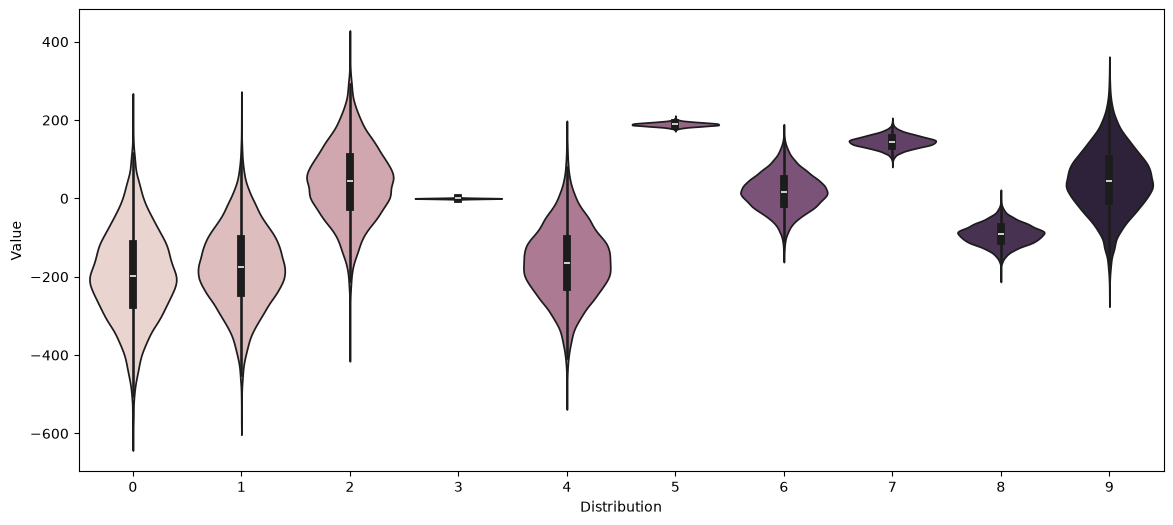

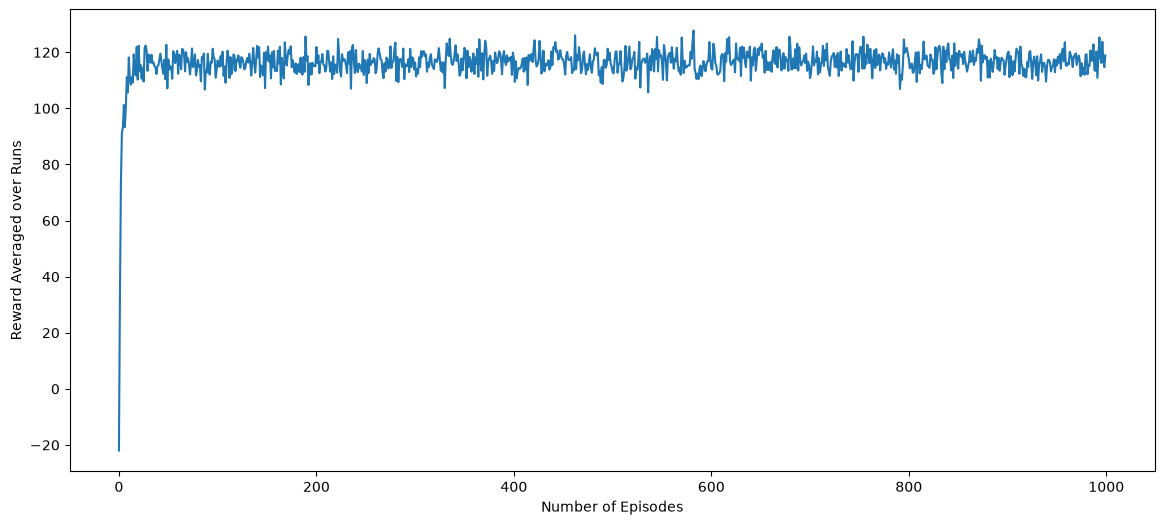

In [9]:
test_greedy_agent()

## Section 3: Epsilon_greedy Agent

We explored another approach for an agent's behavior, known as **epsilon-greedy**, where it does not exclusively choose the greedy action. Instead, the agent occasionally takes exploratory actions to gather more information about the environment. This exploration helps the agent discover the truly optimal action, as it prevents the agent from sticking to its current belief about the best action. Without sufficient exploration, the agent may miss out on potentially better actions and settle on a suboptimal choice. The epsilon-greedy approach introduces a tradeoff between **exploration** (trying new actions) and **exploitation** (choosing the best-known action).

In this approach, with probability $ \epsilon $, the agent selects a random action (exploration). With probability $ 1 - \epsilon $, the agent chooses the action that currently has the highest estimated value (exploitation). The decision-making process can be expressed as:

$$
a_t = 
\begin{cases} 
\text{random action} & \text{with probability } \epsilon \\
\arg\max_a Q(a) & \text{with probability } 1 - \epsilon
\end{cases}
$$

where:
- $ a_t $ is the action chosen at time step $ t $,
- $ Q(a) $ is the estimated value of action $ a $,
- $ \epsilon $ is the probability of taking a random action.

The exploration-exploitation tradeoff is central to the epsilon-greedy method: a higher $ \epsilon $ promotes more exploration, which is useful when the agent is less confident in its value estimates. Conversely, a lower $ \epsilon $ encourages more exploitation, relying on the agent's existing knowledge.

Once the action is selected, the agent updates its value estimates as follows:

$$
Q(a) \leftarrow Q(a) + \alpha \left( R - Q(a) \right)
$$

where:
- $ Q(a) $ is the estimated value of action $ a $,
- $ R $ is the reward received after taking action $ a $,
- $ \alpha $ is the learning rate, controlling how much the value estimate is updated.

Your task is to implement an epsilon-greedy agent. Tip: refer to the algorithm described bellow. You might find it helpful to use the greedy logic from earlier and leverage `np.random.random` and `np.random.randint` for selecting random actions.

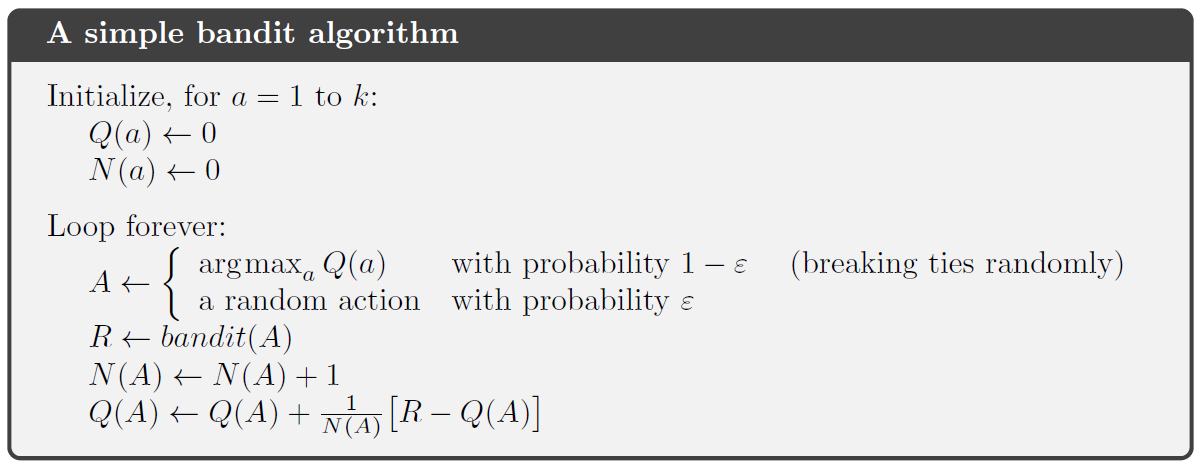

In [10]:
class EpsiGreedyAgent:
    def __init__(self, num_bandits, epsilon=0.1):
        """
        Initializes the Epsilon-Greedy Agent.

        Args:
            num_bandits (int): The number of bandits (actions) available in the environment.
            epsilon (float): The probability of selecting a random action (exploration rate). Defaults to 0.1.

        Initializes:
            - q_values (np.ndarray): An array to store the estimated value of each bandit, initialized to zeros.
            - arm_counts (np.ndarray): An array to track how many times each bandit has been selected, initialized to zeros.
        """
        self.q_values = np.zeros(num_bandits)
        self.arm_counts = np.zeros(num_bandits)
        self.epsilon = epsilon

    def act(self):
        """
        Selects an action using the epsilon-greedy policy.

        With probability `epsilon`, the agent selects a random action (exploration).
        With probability `1 - epsilon`, the agent selects the action with the highest estimated value (exploitation).

        Returns:
            int: The index of the action (bandit) selected.
            - If exploring, the action is chosen randomly.
            - If exploiting, the action with the highest estimated value is selected. In case of ties, 
              the `argmax` function resolves them by selecting one randomly.
        """
        if np.random.rand()>self.epsilon:
            return argmax(self.q_values)
        else:
            return np.random.randint(len(self.q_values))
        

    def learn(self, action, reward):
        """
        Updates the estimated value of a bandit based on the received reward.

        Args:
            action (int): The index of the bandit chosen by the agent.
            reward (float): The reward received after taking the action.

        Updates:
            - The count of times the bandit (action) has been selected.
            - The estimated value of the selected bandit using the formula:
              Q(a) <- Q(a) + (1/N(a))(R - Q(a))
              where:
                - Q(a)is the estimated value of the action,
                - N(a) is the number of times the action has been taken,
                - R is the reward received.
        """
        
        self.arm_counts[action] += 1 
        self.q_values[action] += (1/self.arm_counts[action])*(reward - self.q_values[action])
       
        


Now that we have implemented the epsilon-greedy agent, let’s compare its performance against the greedy agent and the epsilon-greedy agent with an epsilon value of 0.1.

In [24]:

def test_epsigreedy_agent(num_bandits=10, epsilon = 0.1, num_episodes=1000, num_runs=200, draw = True,skip_greedy=False):
    """
    Tests the BanditAgent in the KarmedBanditEnvironment and plots the average reward.

    Args:
        num_bandits: Number of bandits in the environment.
        num_episodes: Number of episodes to run for each run.
        num_runs: Number of independent runs to average over.
    """
    env = KarmedBanditEnvironment(num_bandits)
    if draw:
        env.plot()
    list_plot = []
    if skip_greedy:
        agent_list = [EpsiGreedyAgent]
    else:
        agent_list = [EpsiGreedyAgent,GreedyAgent]
    for i,agent_func in enumerate(agent_list):
        agent_name = ['Epsilon Greedy','Greedy'][i]
        for run in tqdm(range(num_runs)):
            agent = agent_func(num_bandits)
            for episode in range(num_episodes):
                action = agent.act()
                reward = env.step(action)
                agent.learn(action,reward)
                list_plot.append({'agent':agent_name,'run':run,'episode':episode,'reward':reward})
        df = pd.DataFrame(list_plot)
    df_plot = df.groupby(['agent','episode'],as_index=False)['reward'].mean()
    if draw:
        plt.figure(figsize=(14,6))
        sns.lineplot(data=df_plot,
                    x='episode',
                    y='reward',
                    hue='agent')
        plt.xlabel('Number of Episodes')
        plt.ylabel('Reward Averaged over Runs')
    return df,df_plot

100%|██████████| 200/200 [00:01<00:00, 148.57it/s]


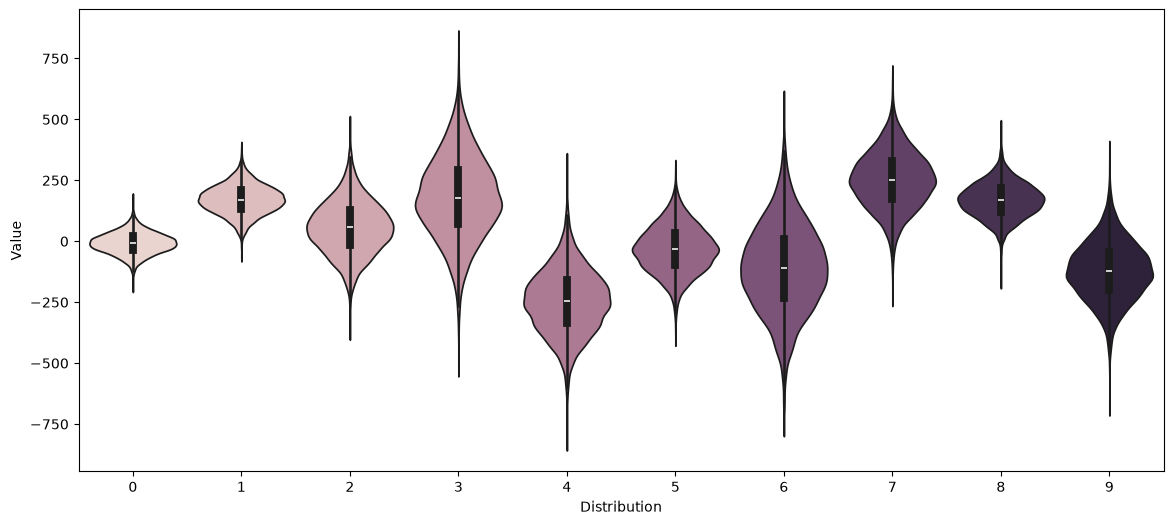

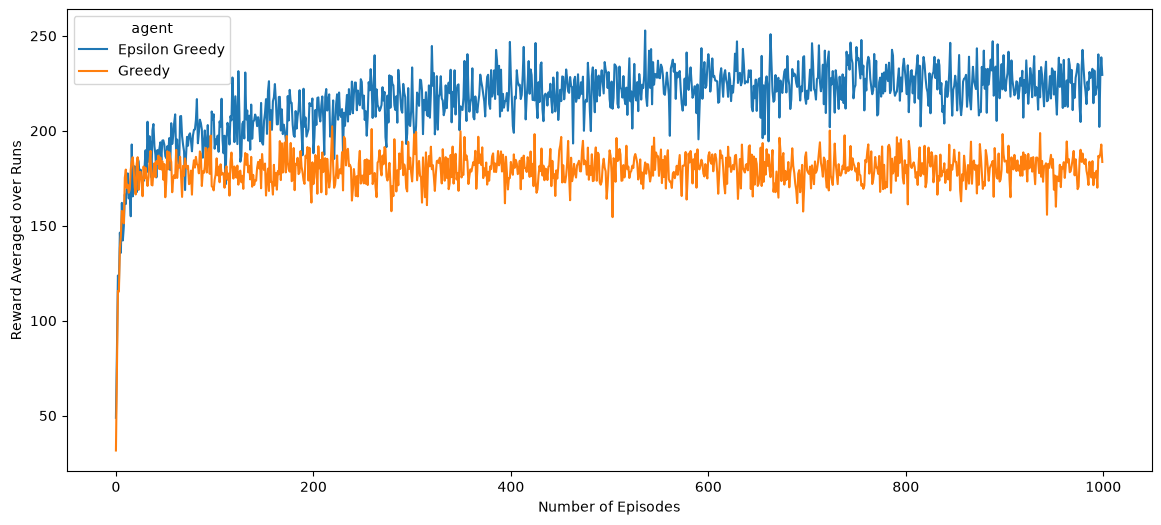

In [12]:
df,df_plot = test_epsigreedy_agent()

Notice how much better the epsilon-greedy agent performed. By occasionally selecting a random action, it was able to discover a more optimal long-term strategy. Acting greedily before our value estimates are fully accurate can lead to settling on a suboptimal action.

## Section 4 : Comparing values of epsilon

Now, let's compare the performance of the epsilon-greedy agent with different values of epsilon. By testing various epsilon values (such as 0.01, 0.1, and 0.4), you can observe how the level of exploration affects the agent's ability to find the optimal action. A smaller epsilon value will result in less exploration, making the agent more greedy, while a larger epsilon value increases exploration, allowing the agent to explore more actions. By analyzing the results, you'll be able to determine the best epsilon value for balancing exploration and exploitation in this particular environment.

In [46]:
"""
In this experiment, you will evaluate the performance of agents with different epsilon values [0.0, 0.01, 0.1, 0.4] in an epsilon-greedy policy. 
The aim is to compare how varying levels of exploration affect the agent's ability to maximize rewards.
"""
results = pd.DataFrame()
for eps in np.linspace(0.1,0.8,10):
    _,df_plot = test_epsigreedy_agent(num_bandits = 30,epsilon=eps,draw=False,num_runs=500,skip_greedy=True,num_episodes=3000)
    df_plot = df_plot[df_plot['agent']=='Epsilon Greedy']
    df_plot['epsilon'] = eps
    results = pd.concat([results,df_plot])


100%|██████████| 500/500 [00:10<00:00, 49.65it/s]


In [47]:
fig = px.line(data_frame=results,
        x='episode',
        y='reward',
        color='epsilon',
        color_discrete_sequence=px.colors.diverging.Spectral)
fig.update_layout(template='plotly_dark')
fig.show()

## Section 5: effect of the step size

Until now, we have used the step size $ \frac{1}{N(a)} $ to adjust the learning rate for action-value estimates. But why is this dynamic step size important? The idea behind this approach is that the more often an action is selected, the more precise its value estimate should be, as the step size decreases over time. This allows the agent to stabilize its value estimates as it gains more experience with specific actions.

However, this leads to an interesting question: what happens if we switch to a constant step size instead of $ \frac{1}{N(a)} $? A constant step size means that the agent’s updates to action-values will always be made with the same rate, regardless of how many times an action has been taken. This approach could be represented by the following update rule:

$$
Q(a) \leftarrow Q(a) + \alpha \left( R - Q(a) \right)
$$

where $ \alpha $ is a constant step size. In previous case, $ \alpha $ was equal to $ \frac{1}{N(a)} $. Let’s explore this idea of constant step size $ \alpha $  and examine its impact on learning and the agent's performance.

In [18]:
class EpsilonGreedyAgentConstantStepsize(EpsiGreedyAgent):
    """
    Epsilon-Greedy Agent with a Constant Step Size for Updating Action-Value Estimates.

    This agent extends the EpsilonGreedyAgent by using a constant step size for updates,
    instead of the default step size that depends on the number of times an action has been selected.
    """
    
    def __init__(self, num_bandits, epsilon=0.1, step_size = 1):
        """
        Initializes the Epsilon-Greedy Agent with a constant step size.

        Args:
            num_bandits (int): The number of bandits (actions) available in the environment.
            epsilon (float): The probability of selecting a random action (exploration rate). Defaults to 0.1.
            step_size (float): The constant step size used to update action-value estimates. Defaults to 1.

        Inherits:
            - q_values (np.ndarray): An array to store the estimated value of each bandit, initialized to zeros.
            - arm_counts (np.ndarray): An array to track how many times each bandit has been selected, initialized to zeros.
        """
        
        super().__init__(num_bandits=num_bandits, epsilon=epsilon)
        self.step_size = step_size
        
    def learn(self, action, reward):
        """
        Updates the estimated value of a bandit based on the received reward, using a constant step size.

        Args:
            action (int): The index of the bandit chosen by the agent.
            reward (float): The reward received after taking the action.

        Updates:
            - The count of times the bandit (action) has been selected.
            - The estimated value of the selected bandit using the formula:
                Q(a) <- Q(a) + alpha(R - Q(a))
              where:
                - Q(a) is the estimated value of the action,
                - alpha is the constant step size,
                - R is the reward received.
        """

        self.arm_counts[action] += 1
        self.q_values[action] += self.step_size * (reward - self.q_values[action])
        

100%|██████████| 200/200 [00:01<00:00, 150.37it/s]


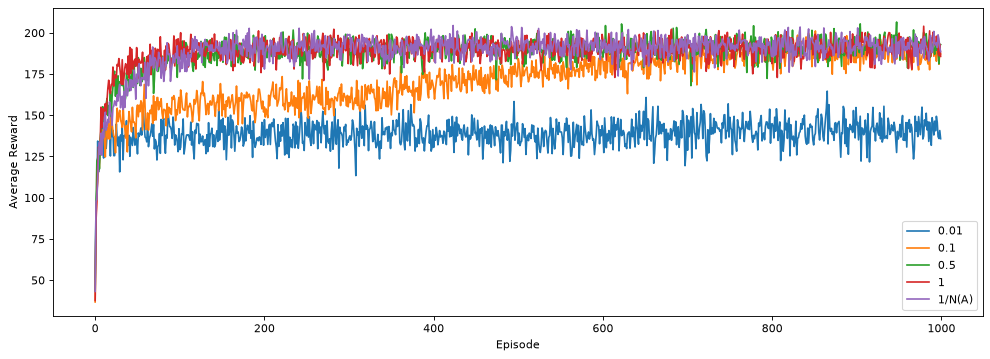

In [19]:
"""
Task: Compare the performance of epsilon-greedy agents with different step sizes.

Run 1000 episodes for each agent and compute the average reward across multiple runs with different strp sizes [0.01, 0.1, 0.5, 1, '1/N(A)']

"""
num_runs = 200
num_episodes = 1000
rewards = np.zeros((num_runs, num_episodes))
num_bandits = 10
env1 = KarmedBanditEnvironment(num_bandits)

plt.figure(figsize=(15, 5), dpi= 80, facecolor='w', edgecolor='k')
steps_size = [0.01, 0.1, 0.5, 1, '1/N(A)']
for step_size in steps_size:
    for run in tqdm(range(num_runs)):
        if step_size != '1/N(A)':
            agent = EpsilonGreedyAgentConstantStepsize(num_bandits = num_bandits, epsilon=0.1, step_size=step_size)
        else:
            agent = EpsiGreedyAgent(num_bandits = num_bandits, epsilon=0.1)
        
        for episode in range(num_episodes):
            action = agent.act()
            reward = env1.step(action)
            agent.learn(action, reward)
            rewards[run, episode] = reward

    average_rewards = np.mean(rewards, axis=0)
    plt.plot(average_rewards, label = step_size)



plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.legend()
plt.show()

In reinforcement learning, one of the challenges that agents face is adapting to changes in the environment. When the environment is stationary, an agent can gradually learn the optimal policy over time. However, in dynamic environments where the reward distribution or other aspects of the environment change, the agent must quickly adjust its strategy. The ability to adapt rapidly is crucial, especially when the agent’s previous knowledge becomes outdated. This is where the choice of step size becomes important. A constant step size may not be ideal for such changing environments because it applies the same update rate regardless of how much new information the agent has gathered. As a result, the agent may struggle to adapt quickly to changes, as it continues to place the same weight on outdated information. On the other hand, a dynamic step size, such as \( \frac{1}{N(a)} $, can help the agent learn faster initially, but as the environment shifts, it may reduce the learning rate, which could delay the adaptation process. Therefore, choosing the right step size is crucial for balancing stability and adaptability in a changing environment.

Implement a change in the environment after a certain number of steps and observe how the agent adjusts its behavior in response to the new conditions.

100%|██████████| 200/200 [00:01<00:00, 148.60it/s]


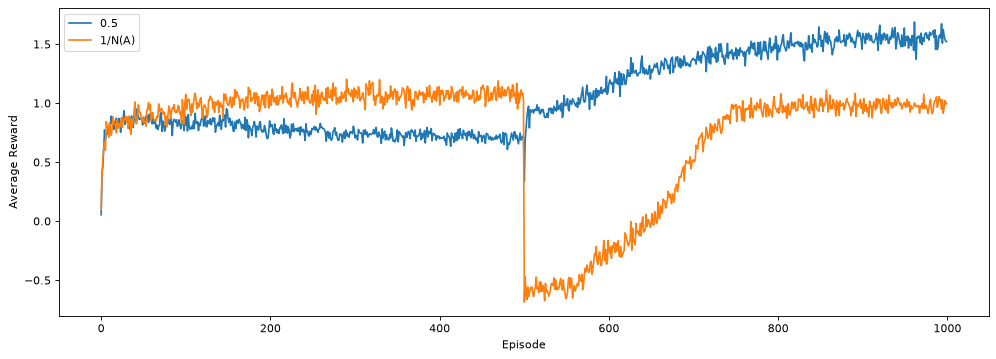

In [33]:
"""
Task: Analyze how agents with different step sizes adapt to a changing environment.

Switch environments after 500 episodes.
Use the following step sizes for comparison: [0.5, '1/N(A)'].
"""

num_episodes = 1000
rewards = np.zeros((num_runs, num_episodes))
num_bandits = 10
env1 = KarmedBanditEnvironment(num_bandits)
env2 = KarmedBanditEnvironment(num_bandits)

plt.figure(figsize=(15, 5), dpi= 80, facecolor='w', edgecolor='k')
steps_size = [0.5, '1/N(A)']
for step_size in steps_size:
    for run in tqdm(range(num_runs)):
        if step_size != '1/N(A)':
            agent = EpsilonGreedyAgentConstantStepsize(num_bandits = num_bandits, epsilon=0.1, step_size=step_size)
        else:
            agent = EpsiGreedyAgent(num_bandits = num_bandits, epsilon=0.1)
        
        for episode in range(num_episodes):
            env = env1 if episode < num_episodes/2 else env2
            action = agent.act()
            reward = env.step(action)
            agent.learn(action, reward)
            rewards[run, episode] = reward

    average_rewards = np.mean(rewards, axis=0)
    plt.plot(average_rewards, label = step_size)



plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.legend()
plt.show()

The agent with a step size of $ \frac{1}{N(a)} $ initially performed better, but its performance deteriorated once the environment changed. What caused this?

Consider the step size after 1000 steps. If the best action was chosen 500 times, the step size for that action would be $ \frac{1}{500} $, or 0.002. When updating the action’s value, the change would be a tiny adjustment (only $ 0.002 \times $ the error) making it slow to approach the true value.

On the other hand, the agent with a constant step size of 0.1 will consistently update the action value by $ \frac{1}{10} $ of the error. This means that, on average, it takes ten steps to bring the value closer to the sample mean.

These are the kinds of trade-offs we must consider in reinforcement learning. A larger step size accelerates the convergence to the true value, but it can lead to oscillations around the expected value. A decaying step size tends to stabilize and gradually converge to the expected value, but it becomes less adaptive when the environment changes. Non-stationarity—and the related challenge of partial observability—are common issues in reinforcement learning, especially when learning in real-time. 